In [3]:
import torch
from torch import nn
!pip install torchviz
from torchviz import make_dot

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[-0.2872]], requires_grad=True)
Parameter containing:
tensor([0.1555], requires_grad=True)
tensor([-0.1317], grad_fn=<ViewBackward0>)
tensor([-0.1317], grad_fn=<AddBackward0>)


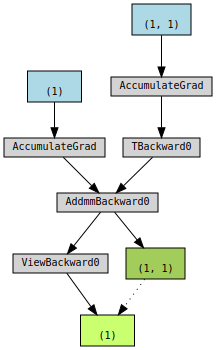

In [ ]:
x = torch.tensor([1.]) # 인공 신경망의 입력은 float 이여야함.
model = nn.Linear(1,1) # 입력 node 한 개, 출력 node 한 개인 layer 만듦
print(model)

print(model.weight) # 만들면서 initialize 자동적으로 함
print(model.bias)   # 미분해서 학습할 변수들이므로 requires_grad=True가 default.

y = model(x)
print(y)

y2 = x @ model.weight + model.bias # 식으로 나타내 본다면 이런 꼴
print(y2)

make_dot(y)

Parameter containing:
tensor([[-0.8270],
        [-0.5671],
        [ 0.4973]], requires_grad=True)
Parameter containing:
tensor([ 0.7092, -0.5852,  0.5263], requires_grad=True)
Parameter containing:
tensor([[-0.1814, -0.0266, -0.2629]], requires_grad=True)
Parameter containing:
tensor([-0.3010], requires_grad=True)
tensor([-0.1177, -1.1524,  1.0237], grad_fn=<ViewBackward0>)
tensor([-0.5181], grad_fn=<ViewBackward0>)
tensor([-0.5181], grad_fn=<AddBackward0>)


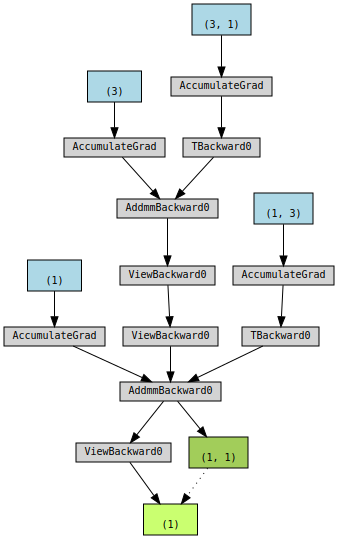

In [ ]:
fc1 = nn.Linear(1,3)
fc2 = nn.Linear(3,1)

print(fc1.weight)
print(fc1.bias)
print(fc2.weight)
print(fc2.bias)
# 균등분포(Uniform) 기반의 Kaiming(He) 초기화를 사용한다.
# weight: Uniform(-1/√n, 1/√n)에서 랜덤 샘플링 (n = in_features)
# bias: 동일하게 Uniform(-1/√n, 1/√n)에서 샘플링 (n = in_features)

x = torch.tensor([1.])
x = fc1(x)
print(x)
y = fc2(x)
print(y)

x = torch.tensor([1.])
y2 = (x@fc1.weight.T + fc1.bias) @ fc2.weight.T + fc2.bias 
# pytorch는 nn.Linear(n,m) 일때 입력 벡터(n,), weight(m,n), bias(m,), 출력 벡터(m,) 으로 주어진다.
# 따라서 행렬곱을 시키려면 weight 행렬을 전치시켜야함.
# 1차원 tensor의 곱은 자동적으로 (1,n) 처럼 1을 임시로 붙여 (1,n) 행렬처럼 취급해 곱셈을 하고 결과에서 1을 다시 제거함.
print(y2)

make_dot(y)

tensor([-0.1618,  0.1719])
tensor([-0.3960,  0.3942,  0.5307], grad_fn=<ViewBackward0>)


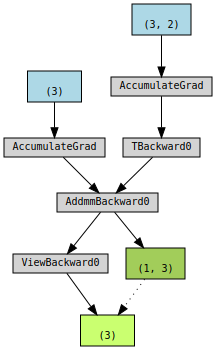

In [ ]:
model = nn.Linear(2,3)
x = torch.randn(2)
print(x)
print(model(x))
# nn.Linear은 데이터의 shape의 마지막 차원이 '채'로(1D data) 들어오길 기대한다.
# 입력 노드 하나가 곧 하나의 채널(피쳐) 값을 의미

make_dot(model(x))

tensor([[ 2.0152, -0.0983],
        [-0.7604, -1.1926],
        [ 0.9438,  1.6245],
        [ 0.5818,  0.1173],
        [-0.8071, -0.7508]])
tensor([[-0.7998,  0.6304,  0.2517],
        [-0.6581, -0.0666,  0.3637],
        [ 0.1126,  1.2214,  0.5845],
        [-0.4145,  0.5835,  0.4149],
        [-0.4717,  0.1062,  0.4278]], grad_fn=<AddmmBackward0>)
torch.Size([4, 5, 3])
torch.Size([2, 3, 6, 4, 5, 3])


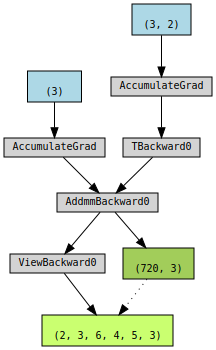

In [ ]:
model = nn.Linear(2,3)
# 따라서, 데이터 여러 개를 통과시키고 싶다면 개x채 의 형태로 줘야함.
x = torch.randn(5,2) # 개x채 => 두 개의 채널 값(키, 몸무게)을 가지는 데이터(사람) 5개

print(x)
print(model(x))

x = torch.randn(4,5,2) # 개x개x채 형태로 들어가는 형태. 5명의 사람으로 이뤄진 4개의 조의 형태를 생각하면 된다.
# LLM에서 5개의 단어를 가진 4개의 문장 이런 형태로 분절시켜서 입력이 가능하다.
print(model(x).shape)

x = torch.randn(2,3,6,4,5,2) # 2개의 학교, 3개의 학년, 6개의 반, 4개의 조, 5명 씩 이뤄진 데이터를 생각하면 된다.
print(model(x).shape)

make_dot(model(x))

# 그렇다면 왜 weight 행렬이 (m,n) 으로 주어질까? => 데이터와 마찬가지로 개x채 형태로 만들기 위함.
# 예를 들어, nn.Linear(2,3) 이면 두 채널 값을 사용하는 세 '개'의 필터를 통과하는 것이라 3x2 가 된다.
# 데이터 개채는 두 채널 값을 가지는 열 개의 데이터 (10x2)
# 웨이트 개채는 두 채널 값을 이용하는 세 개의 필터 (3x2)

tensor([-0.6094,  0.3965,  0.9082], grad_fn=<ViewBackward0>)
tensor([0.1077], grad_fn=<ViewBackward0>)
tensor([0.1077], grad_fn=<ViewBackward0>)


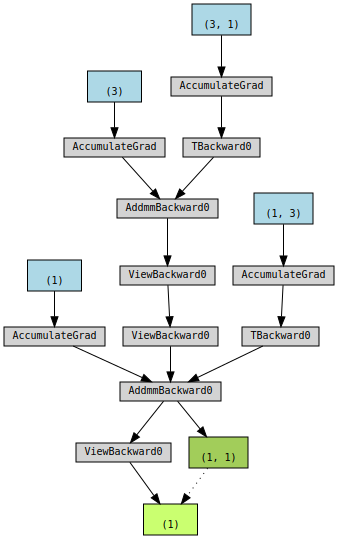

In [ ]:
fc1 = nn.Linear(1,3)
fc2 = nn.Linear(3,1)

x = torch.tensor([1.])
x = fc1(x)
print(x)
x = fc2(x)
print(x)

model = nn.Sequential(fc1,fc2)
x = torch.Tensor([1.])
print(model(x))

make_dot(model(x)) # Sequential 이 그림에 표현되진 않음

In [ ]:
model = nn.Sequential(nn.Linear(2,5), # (in_채널, out_채널) 이니까 연결된느 부분이 같아야 함.
                      nn.Linear(5,10),
                      nn.Linear(10,3))

x = torch.randn(5,2)
print(x)
print(model(x))

tensor([[ 1.3563,  0.6906],
        [ 0.2302, -0.4677],
        [-1.2165, -1.5798],
        [-0.4596,  0.7632],
        [ 0.8055, -0.1359]])
tensor([[ 0.1844, -0.0658,  0.1699],
        [-0.0253, -0.0091,  0.0012],
        [-0.2616,  0.0604, -0.1818],
        [ 0.0169,  0.0082,  0.0719],
        [ 0.0590, -0.0357,  0.0641]], grad_fn=<AddmmBackward0>)


tensor([[0.4597, 0.5979, 0.5345],
        [0.4584, 0.5969, 0.5357],
        [0.4603, 0.5994, 0.5363],
        [0.4595, 0.5982, 0.5359],
        [0.4611, 0.5997, 0.5341]], grad_fn=<SigmoidBackward0>)


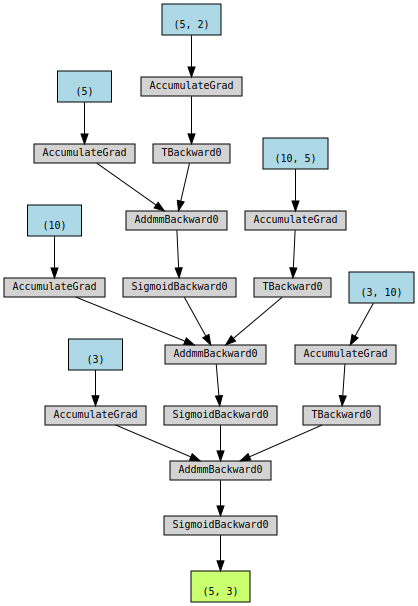

In [18]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2,5)
        self.fc2 = nn.Linear(5,10)
        self.fc3 = nn.Linear(10,3)
        self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        x = self.act(x)
        return x

model = MyModel()
x = torch.randn(5,2)
y = model(x) # model_forward(x) (nn.Module 의 __call__에서 foward를 통과시킴)
print(y)

make_dot(y)

tensor([[0.6609, 0.5949, 0.4350],
        [0.6662, 0.5918, 0.4387],
        [0.6638, 0.5975, 0.4355],
        [0.6656, 0.5947, 0.4374],
        [0.6702, 0.5860, 0.4425]], grad_fn=<SigmoidBackward0>)


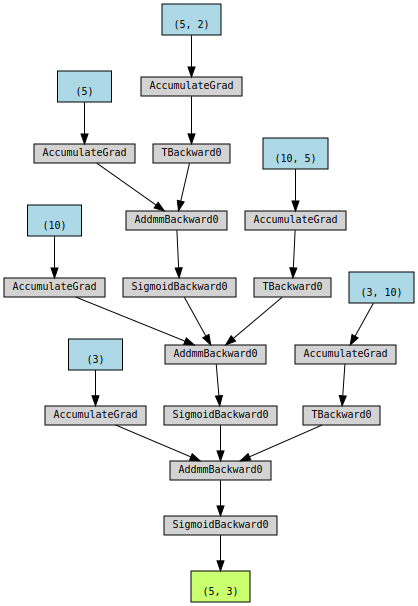

In [20]:
class MyModel2(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(2,5),
                                    nn.Sigmoid(),
                                    nn.Linear(5,10),
                                    nn.Sigmoid(),
                                    nn.Linear(10,3),
                                    nn.Sigmoid())
        
    def forward(self, x):
        x = self.linear(x)
        return x

model2 = MyModel2()
x = torch.randn(5,2)
y = model2(x)
print(y)

make_dot(y)

In [ ]:
print(model2)
print(model2.linear[0].weight)
print(model2.linear[-2].bias) # [-1] 은 Sigmoid() 기 때문에 bias를 가져오려고 하면 오류가 뜸.

MyModel2(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): Sigmoid()
  )
)
Parameter containing:
tensor([[ 0.5815,  0.4972],
        [ 0.1750, -0.6940],
        [ 0.5659,  0.3907],
        [ 0.2689, -0.6391],
        [-0.3499,  0.5771]], requires_grad=True)
Parameter containing:
tensor([0.2047, 0.2915, 0.0546], requires_grad=True)


In [22]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.1196, -0.1741],
         [-0.4083, -0.6232],
         [-0.1993, -0.4896],
         [-0.3775,  0.0836],
         [ 0.1950,  0.2447]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4922, -0.6573, -0.4100, -0.3635, -0.5463], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2244, -0.4266, -0.2883,  0.2856, -0.1385],
         [-0.3975,  0.1412,  0.0298, -0.2900,  0.1366],
         [ 0.1636, -0.2407,  0.0922, -0.2559,  0.2278],
         [-0.3828, -0.2133, -0.0036, -0.0448, -0.0259],
         [-0.1202,  0.3516, -0.1716, -0.4467, -0.1563],
         [-0.1956, -0.1197, -0.0221, -0.1948,  0.0073],
         [-0.2515, -0.0921,  0.1656, -0.1811,  0.3511],
         [ 0.1143,  0.2188, -0.4094, -0.3252,  0.1308],
         [ 0.1573, -0.3544,  0.4238, -0.3164, -0.3296],
         [ 0.4409,  0.4390,  0.0142,  0.4199, -0.2198]], requires_grad=True),
 Parameter containing:
 tensor([ 0.3475, -0.1916,  0.2856,  0.2449, -0.4453,  0.1651,  0.0683,  0.3409,
  

In [23]:
# 파라미터 수 구하기
num = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(num)

108
